# Lesson 2: How a model learns

**Why:** a model is just a formula with adjustable numbers in it, called **parameters**. "Learning" means adjusting those numbers until the model's answers match the examples. Our GPT will have about 800,000 parameters. Today's model has **2**, but it learns in exactly the same way.

**The learning loop:**
```
 guess ──► measure the error ──► work out which way ──► nudge the numbers ──┐
   ▲         (loss)               to nudge each one      a little            │
   │                              (gradient)                                 │
   └─────────────────────────────── repeat ◄─────────────────────────────────┘
```

**Today's puzzle:** there's a secret rule, **y = 2x + 1**. The model is `prediction = w·x + b`, and it starts with **random** `w` and `b`. Can it discover 2 and 1 just from seeing examples?

## 1. A random guess, and how wrong it is

**Loss** measures how wrong the model is, as one number:

$$\text{loss} = \text{average of } (\text{prediction} - \text{truth})^2$$

Squaring means misses in either direction count (they can't cancel out), and big misses count a lot more. **0 = perfect.**

`requires_grad=True` tells PyTorch: "keep track of how this number affects the result, because we'll want to adjust it".

In [1]:
import torch
import matplotlib.pyplot as plt

torch.manual_seed(0)

x = torch.linspace(-1, 1, 20)   # 20 example inputs between -1 and 1
y = 2 * x + 1                   # the secret rule the model must discover

w = torch.randn(1, requires_grad=True)   # random starting guesses
b = torch.randn(1, requires_grad=True)

pred = w * x + b
loss = ((pred - y) ** 2).mean()          # mean squared error
print(f"start: w={w.item():.3f}  b={b.item():.3f}  loss={loss.item():.3f}")

start: w=1.541  b=-0.293  loss=1.751


## 2. The gradient: which way to nudge

`loss.backward()` makes PyTorch work out a **gradient** for each parameter. It answers: *"if I increase this number a tiny bit, does the loss go up or down, and how strongly?"*

- Gradient **positive**: increasing the number makes things worse, so **decrease** it.
- Gradient **negative**: increasing it helps, so **increase** it.

So the update rule is always **move against the gradient**:

$$w_{\text{new}} = w - \text{learning rate} \times \text{gradient}$$

The **learning rate** is the step size.

In [2]:
loss.backward()
print(f"w.grad = {w.grad.item():.3f}")
print(f"b.grad = {b.grad.item():.3f}")

w.grad = -0.338
b.grad = -2.587


## 3. Repeat 100 times, and watch it learn

This is the whole idea: guess, measure, nudge, repeat. Watch `w` and `b` move toward 2 and 1.

(`torch.no_grad()` means "this is just the nudge, don't track it". We clear the old gradients each step, because PyTorch would otherwise add the new ones on top.)

In [3]:
lr = 0.1          # learning rate (step size)
history = []

for step in range(100):
    w.grad = None; b.grad = None       # clear last step's gradients
    pred = w * x + b                   # guess
    loss = ((pred - y) ** 2).mean()    # measure the error
    loss.backward()                    # which way to nudge
    with torch.no_grad():              # nudge
        w -= lr * w.grad
        b -= lr * b.grad
    history.append(loss.item())
    if step % 20 == 0 or step == 99:
        print(f"step {step:3d}:  w={w.item():.3f}  b={b.item():.3f}  loss={loss.item():.5f}")

step   0:  w=1.575  b=-0.035  loss=1.75058
step  20:  w=1.908  b=0.988  loss=0.00386
step  40:  w=1.980  b=1.000  loss=0.00017
step  60:  w=1.996  b=1.000  loss=0.00001
step  80:  w=1.999  b=1.000  loss=0.00000
step  99:  w=2.000  b=1.000  loss=0.00000


## 4. See it

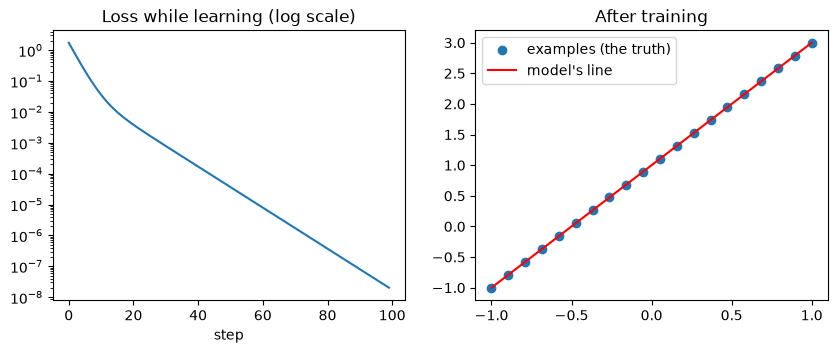

In [4]:
fig, (left, right) = plt.subplots(1, 2, figsize=(10, 3.5))

left.plot(history)
left.set_yscale("log")
left.set_title("Loss while learning (log scale)")
left.set_xlabel("step")

right.scatter(x, y, label="examples (the truth)")
right.plot(x, (w * x + b).detach(), color="red", label="model's line")
right.set_title("After training")
right.legend()
plt.show()

## 5. The same thing with PyTorch's ready-made tools

PyTorch has building blocks for all of this:
- **`nn.Linear`**: holds `w` and `b` for us (the same "multiply and add" as Lesson 1's `@`).
- **An optimizer (`SGD`)**: does the nudging for every parameter.

The result is the **5-step training loop**. **This exact loop trains our GPT later.** Only the model and the data change.

In [5]:
import torch.nn as nn

model = nn.Linear(1, 1)                                  # its own w and b
optimizer = torch.optim.SGD(model.parameters(), lr=0.1)

X = x.view(-1, 1)   # (20, 1): nn.Linear wants (examples, features)
Y = y.view(-1, 1)

for step in range(100):
    pred = model(X)                    # 1. forward: make a guess
    loss = ((pred - Y) ** 2).mean()    # 2. loss: how wrong?
    optimizer.zero_grad()              # 3. clear old gradients
    loss.backward()                    # 4. backward: work out gradients
    optimizer.step()                   # 5. step: nudge every parameter

print(f"learned: w={model.weight.item():.3f}  b={model.bias.item():.3f}  loss={loss.item():.6f}")

learned: w=1.999  b=1.000  loss=0.000001


## 6. Experiment: step size matters

We train three fresh models for 50 steps each, with learning rates **0.01**, **0.1** and **1.1**.

**Predict:** which one ends closest to w = 2, b = 1? What do you think happens to the other two?

lr=0.01  -> w=     0.613  b=     0.831  final loss=0.7489
lr=0.1   -> w=     1.956  b=     1.000  final loss=0.0008204
lr=1.1   -> w=     2.000  b= -4217.577  final loss=1.236e+07


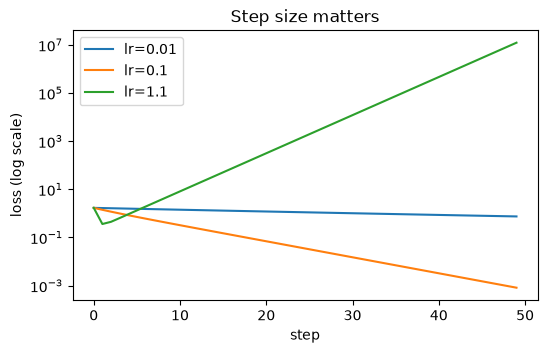

In [6]:
def train(lr, steps=50):
    torch.manual_seed(0)
    m = nn.Linear(1, 1)
    opt = torch.optim.SGD(m.parameters(), lr=lr)
    losses = []
    for _ in range(steps):
        loss = ((m(X) - Y) ** 2).mean()
        opt.zero_grad(); loss.backward(); opt.step()
        losses.append(loss.item())
    return m, losses

plt.figure(figsize=(6, 3.5))
for lr in [0.01, 0.1, 1.1]:
    m, losses = train(lr)
    print(f"lr={lr:<5} -> w={m.weight.item():10.3f}  b={m.bias.item():10.3f}  final loss={losses[-1]:.4g}")
    plt.plot(losses, label=f"lr={lr}")
plt.yscale("log"); plt.xlabel("step"); plt.ylabel("loss (log scale)")
plt.title("Step size matters"); plt.legend(); plt.show()

## 7. Final check

In [7]:
assert abs(model.weight.item() - 2) < 0.01 and abs(model.bias.item() - 1) < 0.01
print("The model found the rule y = 2x + 1 on its own. Lesson 2 complete.")

The model found the rule y = 2x + 1 on its own. Lesson 2 complete.


## Wrap-up question

In your own words: what are the **5 steps** of the training loop, and which step actually changes the model?